In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

c:\Users\yamaw\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.34M/1.34M [00:00<00:00, 1.80MB/s]

Extracting files...
Path to dataset files: C:\Users\yamaw\.cache\kagglehub\datasets\shivamb\netflix-shows\versions\5


In [2]:
import pandas as pd
import os

csv_path = os.path.join(path, "netflix_titles.csv")

df = pd.read_csv(csv_path)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.columns = [
    "ID",
    "タイプ",
    "タイトル",
    "監督",
    "キャスト",
    "国",
    "追加日",
    "公開年",
    "レコーディング",
    "再生時間",
    "ジャンル",
    "あらすじ"
]
df.head()

,ID,タイプ,タイトル,監督,キャスト,国,追加日,公開年,レコーディング,再生時間,ジャンル,あらすじ
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
# 国が「Japan」の者だけに絞った新しいDataFrameを作成する
japan_df = df[df["国"] == "Japan"].copy()

# 必要な列だけに絞り込む
japan_df = japan_df[[
    "タイプ",
    "タイトル",
    "監督",
    "ジャンル",
    "公開年",
]]

print(f"日本の作品数：{len(japan_df)}件")
japan_df.head()

日本の作品数：245件


,タイプ,タイトル,監督,ジャンル,公開年
51,Movie,InuYasha the Movie 2: The Castle Beyond the Lo...,Toshiya Shinohara,"Action & Adventure, Anime Features, Internatio...",2002
52,Movie,InuYasha the Movie 3: Swords of an Honorable R...,Toshiya Shinohara,"Action & Adventure, Anime Features, Internatio...",2003
53,Movie,InuYasha the Movie 4: Fire on the Mystic Island,Toshiya Shinohara,"Action & Adventure, Anime Features, Internatio...",2004
54,Movie,InuYasha the Movie: Affections Touching Across...,Toshiya Shinohara,"Action & Adventure, Anime Features, Internatio...",2001
56,Movie,Naruto Shippuden the Movie: Blood Prison,Masahiko Murata,"Action & Adventure, Anime Features, Internatio...",2011


In [ ]:
# 欠損値を確認してみる
japan_df.isnull().sum()

タイプ       0
タイトル      0
監督      160
ジャンル      0
公開年       0
dtype: int64

In [ ]:
# 'タイプ'には何が含まれているのか
japan_df["タイプ"].unique()

array(['Movie', 'TV Show'], dtype=object)

In [12]:
# 'タイプ'がMovieの者だけ抜き出す
japan_movies = japan_df[japan_df["タイプ"] == "Movie"].copy()

# 欠損値をもう一度確認
japan_movies.isnull().sum()

タイプ     0
タイトル    0
監督      1
ジャンル    0
公開年     0
dtype: int64

In [13]:
# 監督が欠損している（NaN）行だけ取り出してみる
japan_movies[japan_movies["監督"].isnull()]

,タイプ,タイトル,監督,ジャンル,公開年
3712,Movie,Hikaru Utada Laughter in the Dark Tour 2018,NaN,"International Movies, Music & Musicals",2018


In [14]:
# 監督が欠損値の行を削除する
japan_movies = japan_movies.dropna(subset=["監督"])

# 欠損値が完全に0になったか確認
japan_movies.isnull().sum()

タイプ     0
タイトル    0
監督      0
ジャンル    0
公開年     0
dtype: int64

In [16]:
# 公開年の最小値と最大値を確認
print(f"一番古い作品の公開年：{japan_movies["公開年"].min()}")
print(f"一番新しい作品の公開年：{japan_movies["公開年"].max()}")

movie_count = len(japan_movies)
print(f"日本発の映画の総数：{movie_count}作品")

一番古い作品の公開年：1979
一番新しい作品の公開年：2021
日本発の映画の総数：75作品


In [17]:
recent_movies = japan_movies[japan_movies["公開年"] >= 2010]
print(f"2010年以降の作品数：{len(recent_movies)}作品")

2010年以降の作品数：58作品


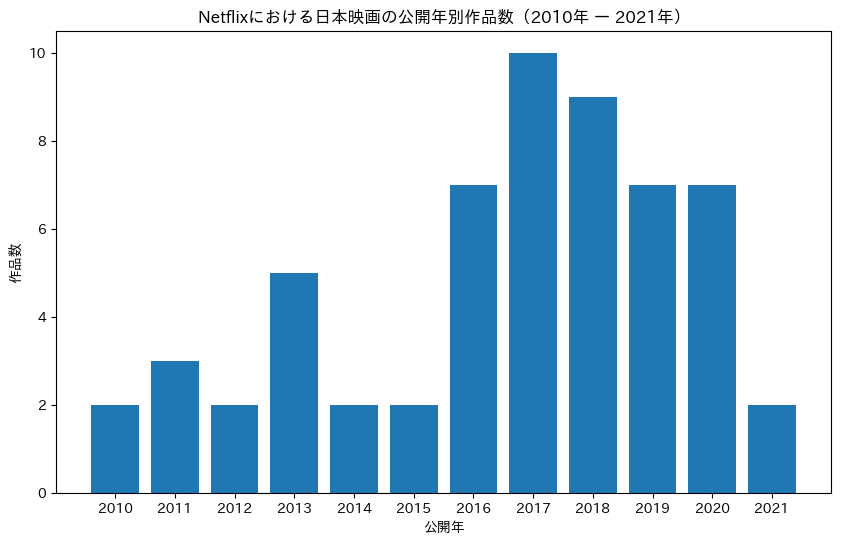

In [19]:
# 公開年ごとに集計して棒グラフを作成してみる
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt
import japanize_matplotlib

recent_year_counts = recent_movies["公開年"].value_counts().sort_index()

# グラフのサイズを設定
plt.figure(figsize=(10, 6))

# 棒グラフを作成
plt.bar(recent_year_counts.index, recent_year_counts.values)

# タイトルとラベルをつける
plt.title("Netflixにおける日本映画の公開年別作品数（2010年 ー 2021年）")
plt.xlabel("公開年")
plt.ylabel("作品数")

plt.xticks(recent_year_counts.index)

plt.show()


In [23]:
# 2017年の日本映画だけを抽出して表示
movie_2017 = recent_movies[recent_movies["公開年"] == 2017]
display(movie_2017)

,タイプ,タイトル,監督,ジャンル,公開年
1131,Movie,Seven Souls in the Skull Castle: Season Flower,Hidenori Inoue,"Action & Adventure, Dramas, International Movies",2017
1965,Movie,High & Low The Movie 2 / End of Sky,"Shigeaki Kubo, Tsuyoshi Nakakuki","Action & Adventure, International Movies",2017
1966,Movie,High & Low The Movie 3 / Final Mission,"Shigeaki Kubo, Tsuyoshi Nakakuki","Action & Adventure, International Movies",2017
2803,Movie,Lu Over the Wall,Masaaki Yuasa,"Anime Features, Music & Musicals, Sci-Fi & Fan...",2017
3098,Movie,Fireworks,"Akiyuki Shinbo, Nobuyuki Takeuchi","Anime Features, Romantic Movies",2017
3170,Movie,No Game No Life: Zero,Atsuko Ishizuka,"Action & Adventure, Anime Features, Internatio...",2017
4223,Movie,Pokémon the Movie: I Choose You!,Kunihiko Yuyama,"Anime Features, Children & Family Movies",2017
5033,Movie,FullMetal Alchemist,Fumihiko Sori,"Action & Adventure, Dramas, International Movies",2017
5476,Movie,BLAME!,Hiroyuki Seshita,"Action & Adventure, Anime Features, Internatio...",2017
7416,Movie,Mary and the Witch's Flower,Hiromasa Yonebayashi,"Anime Features, Children & Family Movies",2017


In [25]:
# タイトルを日本語に変換
translation_dict = {
    "Seven Souls in the Skull Castle: Season Flower": "劇団☆新感線『髑髏城の七人』Season花",
    "High & Low The Movie 2 / End of Sky": "HiGH&LOW THE MOVIE 2 / END OF SKY",
    "High & Low The Movie 3 / Final Mission": "HiGH&LOW THE MOVIE 3 / FINAL MISSION",
    "Lu Over the Wall": "夜明け告げるルーのうた",
    "Fireworks": "打ち上げ花火、下から見るか？横から見るか？",
    "No Game No Life: Zero": "ノーゲーム・ノーライフ ゼロ",
    "Pokémon the Movie: I Choose You!": "劇場版ポケットモンスター キミにきめた！",
    "FullMetal Alchemist": "鋼の錬金術師 (実写版)",
    "BLAME!": "BLAME! (ブラム)",
    "Mary and the Witch's Flower": "メアリと魔女の花"
}

movie_2017_jp = movie_2017.copy()
movie_2017_jp["タイトル"] = movie_2017_jp["タイトル"].replace(translation_dict)
# 日本語になったリストを表示
display(movie_2017_jp[["タイトル", "ジャンル", "監督"]])

,タイトル,ジャンル,監督
1131,劇団☆新感線『髑髏城の七人』Season花,"Action & Adventure, Dramas, International Movies",Hidenori Inoue
1965,HiGH&LOW THE MOVIE 2 / END OF SKY,"Action & Adventure, International Movies","Shigeaki Kubo, Tsuyoshi Nakakuki"
1966,HiGH&LOW THE MOVIE 3 / FINAL MISSION,"Action & Adventure, International Movies","Shigeaki Kubo, Tsuyoshi Nakakuki"
2803,夜明け告げるルーのうた,"Anime Features, Music & Musicals, Sci-Fi & Fan...",Masaaki Yuasa
3098,打ち上げ花火、下から見るか？横から見るか？,"Anime Features, Romantic Movies","Akiyuki Shinbo, Nobuyuki Takeuchi"
3170,ノーゲーム・ノーライフ ゼロ,"Action & Adventure, Anime Features, Internatio...",Atsuko Ishizuka
4223,劇場版ポケットモンスター キミにきめた！,"Anime Features, Children & Family Movies",Kunihiko Yuyama
5033,鋼の錬金術師 (実写版),"Action & Adventure, Dramas, International Movies",Fumihiko Sori
5476,BLAME! (ブラム),"Action & Adventure, Anime Features, Internatio...",Hiroyuki Seshita
7416,メアリと魔女の花,"Anime Features, Children & Family Movies",Hiromasa Yonebayashi
